# 02 Funnel Analysis - Olist Transaction Journey

本 notebook 聚焦 Olist 交易链路漏斗：`下单 -> 支付 -> 发货 -> 签收 -> 评价`，并验证一个关键增长假设：物流时效越长，差评率越高。

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

ROOT = Path.cwd()
if not (ROOT / 'sql').exists():
    ROOT = ROOT.parent
DB_PATH = ROOT / 'data' / 'raw' / 'olist.sqlite'
SQL_PATHS = [
    ROOT / 'sql' / 'metrics_v0.sql',
    ROOT / 'sql' / 'funnel_analysis.sql',
]

if not DB_PATH.exists():
    raise FileNotFoundError(f'Missing database: {DB_PATH}')

conn = sqlite3.connect(DB_PATH)
for sql_path in SQL_PATHS:
    conn.executescript(sql_path.read_text())

print(f'Connected to: {DB_PATH}')

Matplotlib is building the font cache; this may take a moment.


Connected to: /Users/hanqin/internet_ds_project/data/raw/olist.sqlite


## 1. Overall Funnel

先看全量订单在五个阶段的绝对量与阶段转化率。

In [2]:
funnel = pd.read_sql_query(
    '''
    SELECT *
    FROM v_funnel_overall
    ''',
    conn,
)

funnel['stage_conversion'] = funnel['orders'] / funnel['orders'].shift(1)
funnel.loc[0, 'stage_conversion'] = 1.0
funnel['overall_conversion'] = funnel['orders'] / funnel.loc[0, 'orders']
funnel

,stage,orders,stage_conversion,overall_conversion
0,下单,99441,1.000000,1.000000
1,支付,99438,0.999970,0.999970
2,发货,97658,0.982099,0.982070
3,签收,96476,0.987897,0.970183
4,评价,98673,1.022773,0.992277


/var/folders/qs/6kfpsmtj2m5b3nrx4tsvn1c40000gn/T/ipykernel_7766/2273457942.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=funnel, x='stage', y='orders', palette='Blues_d')
/var/folders/qs/6kfpsmtj2m5b3nrx4tsvn1c40000gn/T/ipykernel_7766/2273457942.py:9: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qs/6kfpsmtj2m5b3nrx4tsvn1c40000gn/T/ipykernel_7766/2273457942.py:9: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qs/6kfpsmtj2m5b3nrx4tsvn1c40000gn/T/ipykernel_7766/2273457942.py:9: UserWarning: Glyph 25903 (\N{CJK UNIFIED IDEOGRAPH-652F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qs/6kfpsmtj2m5b3nrx4tsvn1c40000gn/T/ipykernel_7766/2273457942.py:9: UserWarning: Glyp

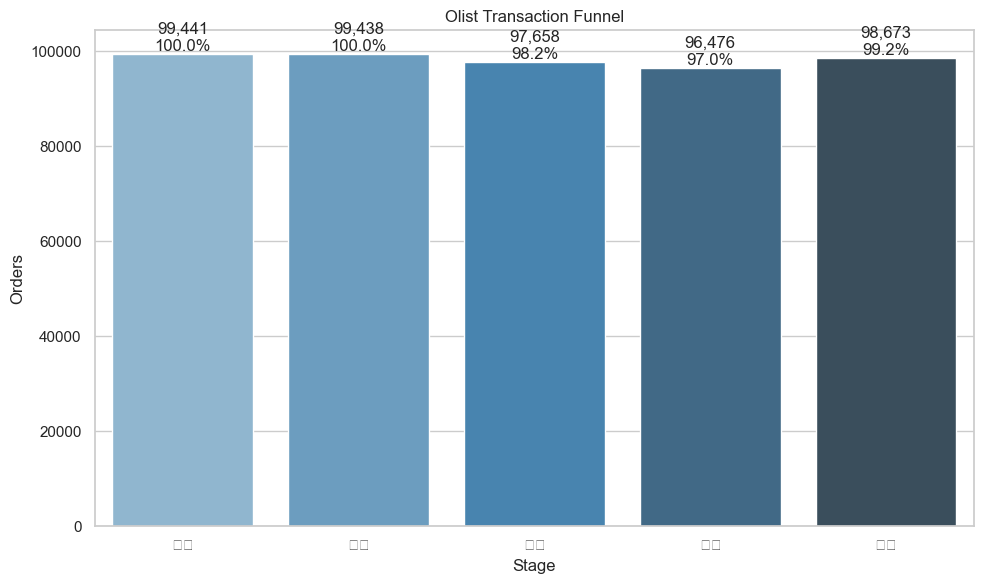

In [3]:
ax = sns.barplot(data=funnel, x='stage', y='orders', palette='Blues_d')
ax.set_title('Olist Transaction Funnel')
ax.set_xlabel('Stage')
ax.set_ylabel('Orders')

for idx, row in funnel.iterrows():
    ax.text(idx, row['orders'], f"{int(row['orders']):,}\n{row['overall_conversion']:.1%}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 2. Monthly Funnel Trend

按购买月份看漏斗变化，判断是否存在某一时期支付、履约或评价转化的明显恶化。

In [4]:
funnel_monthly = pd.read_sql_query(
    '''
    WITH monthly AS (
      SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        SUM(step_purchase) AS purchase_orders,
        SUM(step_payment) AS payment_orders,
        SUM(step_shipped) AS shipped_orders,
        SUM(step_delivered) AS delivered_orders,
        SUM(step_reviewed) AS reviewed_orders
      FROM v_funnel_order
      WHERE order_purchase_timestamp IS NOT NULL
      GROUP BY 1
    )
    SELECT
      month,
      purchase_orders,
      payment_orders * 1.0 / NULLIF(purchase_orders, 0) AS purchase_to_payment,
      shipped_orders * 1.0 / NULLIF(payment_orders, 0) AS payment_to_ship,
      delivered_orders * 1.0 / NULLIF(shipped_orders, 0) AS ship_to_delivered,
      reviewed_orders * 1.0 / NULLIF(delivered_orders, 0) AS delivered_to_review
    FROM monthly
    ORDER BY month
    ''',
    conn,
)

funnel_monthly.tail()

,month,purchase_orders,purchase_to_payment,payment_to_ship,ship_to_delivered,delivered_to_review
20,2018-06,6167,1.000000,0.995946,0.992511,1.007382
21,2018-07,6292,1.000000,0.988398,0.989870,1.014782
22,2018-08,6512,0.999693,0.982796,0.992654,1.021099
23,2018-09,16,0.937500,0.066667,0.000000,NaN
24,2018-10,4,1.000000,0.000000,NaN,NaN


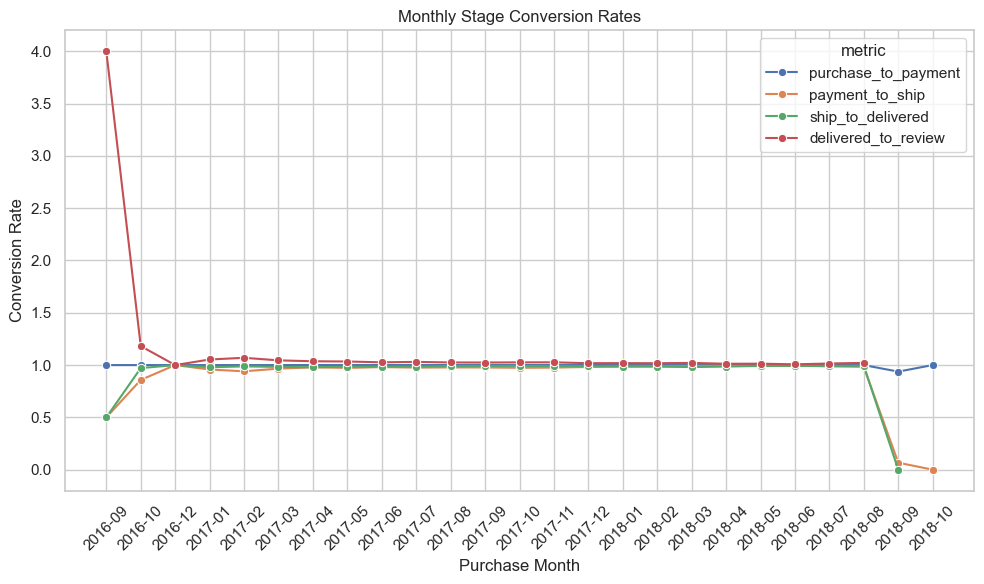

In [5]:
monthly_rates = funnel_monthly.melt(
    id_vars='month',
    value_vars=['purchase_to_payment', 'payment_to_ship', 'ship_to_delivered', 'delivered_to_review'],
    var_name='metric',
    value_name='rate'
)

ax = sns.lineplot(data=monthly_rates, x='month', y='rate', hue='metric', marker='o')
ax.set_title('Monthly Stage Conversion Rates')
ax.set_xlabel('Purchase Month')
ax.set_ylabel('Conversion Rate')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Hypothesis Check: Logistics Delay vs Bad Review

把已签收且已评价订单按物流时长分桶，观察差评率是否随时长上升。

In [6]:
delay_bins = pd.read_sql_query(
    '''
    WITH base AS (
      SELECT
        order_id,
        purchase_to_delivered_days,
        delivery_delay_vs_estimate_days,
        review_score,
        is_bad_review,
        CASE
          WHEN purchase_to_delivered_days < 3 THEN '0-3d'
          WHEN purchase_to_delivered_days < 7 THEN '3-7d'
          WHEN purchase_to_delivered_days < 14 THEN '7-14d'
          WHEN purchase_to_delivered_days < 21 THEN '14-21d'
          ELSE '21d+'
        END AS delivery_speed_bucket,
        CASE
          WHEN delivery_delay_vs_estimate_days <= 0 THEN 'On time or early'
          WHEN delivery_delay_vs_estimate_days <= 3 THEN '1-3d late'
          WHEN delivery_delay_vs_estimate_days <= 7 THEN '4-7d late'
          ELSE '7d+ late'
        END AS estimate_gap_bucket
      FROM v_funnel_order
      WHERE step_delivered = 1
        AND step_reviewed = 1
        AND purchase_to_delivered_days IS NOT NULL
        AND review_score IS NOT NULL
    )
    SELECT
      delivery_speed_bucket,
      COUNT(*) AS orders,
      AVG(review_score) AS avg_review_score,
      AVG(is_bad_review) AS bad_review_rate
    FROM base
    GROUP BY 1
    ORDER BY CASE delivery_speed_bucket
      WHEN '0-3d' THEN 1
      WHEN '3-7d' THEN 2
      WHEN '7-14d' THEN 3
      WHEN '14-21d' THEN 4
      ELSE 5
    END
    ''',
    conn,
)

delay_bins

,delivery_speed_bucket,orders,avg_review_score,bad_review_rate
0,0-3d,4733,4.483203,0.066343
1,3-7d,21199,4.403840,0.076277
2,7-14d,40001,4.311817,0.089648
3,14-21d,17582,4.138892,0.116767
4,21d+,12315,3.119935,0.382136


/var/folders/qs/6kfpsmtj2m5b3nrx4tsvn1c40000gn/T/ipykernel_7766/3366796229.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=delay_bins, x='delivery_speed_bucket', y='bad_review_rate', palette='flare')


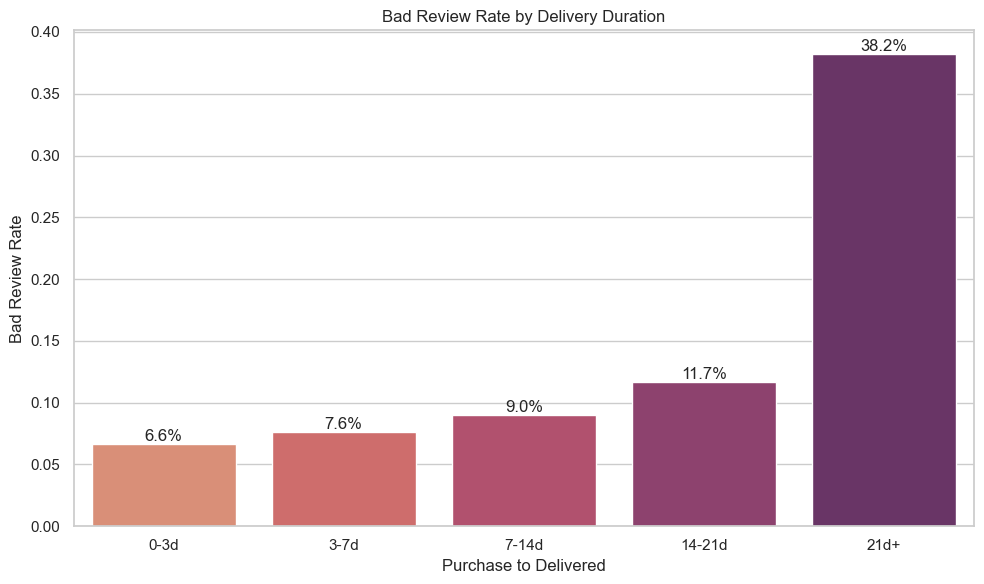

In [7]:
ax = sns.barplot(data=delay_bins, x='delivery_speed_bucket', y='bad_review_rate', palette='flare')
ax.set_title('Bad Review Rate by Delivery Duration')
ax.set_xlabel('Purchase to Delivered')
ax.set_ylabel('Bad Review Rate')

for idx, row in delay_bins.iterrows():
    ax.text(idx, row['bad_review_rate'], f"{row['bad_review_rate']:.1%}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [8]:
estimate_gap = pd.read_sql_query(
    '''
    WITH base AS (
      SELECT
        CASE
          WHEN delivery_delay_vs_estimate_days <= 0 THEN 'On time or early'
          WHEN delivery_delay_vs_estimate_days <= 3 THEN '1-3d late'
          WHEN delivery_delay_vs_estimate_days <= 7 THEN '4-7d late'
          ELSE '7d+ late'
        END AS estimate_gap_bucket,
        review_score,
        is_bad_review
      FROM v_funnel_order
      WHERE step_delivered = 1
        AND step_reviewed = 1
        AND delivery_delay_vs_estimate_days IS NOT NULL
        AND review_score IS NOT NULL
    )
    SELECT
      estimate_gap_bucket,
      COUNT(*) AS orders,
      AVG(review_score) AS avg_review_score,
      AVG(is_bad_review) AS bad_review_rate
    FROM base
    GROUP BY 1
    ORDER BY CASE estimate_gap_bucket
      WHEN 'On time or early' THEN 1
      WHEN '1-3d late' THEN 2
      WHEN '4-7d late' THEN 3
      ELSE 4
    END
    ''',
    conn,
)

estimate_gap

,estimate_gap_bucket,orders,avg_review_score,bad_review_rate
0,On time or early,88168,4.293973,0.092256
1,1-3d late,2636,3.765933,0.191199
2,4-7d late,1773,2.316413,0.613085
3,7d+ late,3253,1.727636,0.784199


/var/folders/qs/6kfpsmtj2m5b3nrx4tsvn1c40000gn/T/ipykernel_7766/287554755.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=estimate_gap, x='estimate_gap_bucket', y='bad_review_rate', palette='magma')


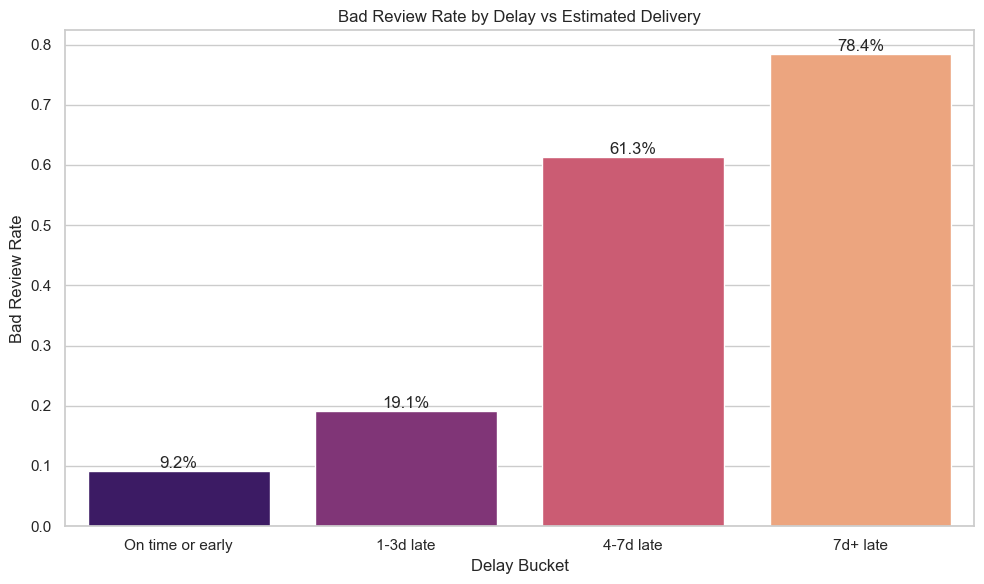

In [9]:
ax = sns.barplot(data=estimate_gap, x='estimate_gap_bucket', y='bad_review_rate', palette='magma')
ax.set_title('Bad Review Rate by Delay vs Estimated Delivery')
ax.set_xlabel('Delay Bucket')
ax.set_ylabel('Bad Review Rate')

for idx, row in estimate_gap.iterrows():
    ax.text(idx, row['bad_review_rate'], f"{row['bad_review_rate']:.1%}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 4. Interpretation

基于当前跑数结果，可以直接写出三点结论：

- 交易链路前半段整体健康，`支付 -> 发货` 转化率约为 `98.21%`，`发货 -> 签收` 转化率约为 `98.79%`，说明主要问题不在支付，而在后续履约体验与复购。
- 物流时长越长，差评率越高：`0-3d` 履约订单差评率为 `6.63%`，而 `21d+` 履约订单差评率升至 `38.21%`；若按承诺时效看，`On time or early` 的差评率为 `9.23%`，`7d+ late` 则高达 `78.42%`。
- 假设得到数据支持，业务上应优先治理晚到订单，尤其是 `4 天以上晚到` 和 `21 天以上总履约时长` 的订单，并配合异常补偿、主动客服和 SLA 优化来降低差评与复购流失。